In [1]:
# Example usage
products_json = {
    "variants": [
        {
            "title": "Mouse Pad",
            "description": "A mouse pad for your mouse",
            "id": "my_mousepad_id",
            "canvas_size": 3000,
            "is_3d_model": True,
            "model_path": "mousepad_3D.glb",
            "thumbnail_url": "https://www.google.com/images/branding/googlelogo/1x/googlelogo_color_272x92dp.png",
            "default_texture_id": "my_mousepad_texture",
            "textures": [
                {
                    "id": "my_mousepad_texture",
                    "type": "image",
                    "content": "test.png",
                    "source_size": {
                        "width": 708,
                        "height": 590,
                        "alignment": {
                            "horizontal": "center",
                            "vertical": "top"
                        }
                    },
                    "canvas_position": {
                        "x": 0,
                        "y": 0,
                        "width": 1500,
                        "height": 1500
                    },
                    "user_modifications": {
                        "position": {
                            "x": 0,
                            "y": 0
                        },
                        "scale": 1.0,
                        "alignment": {
                            "horizontal": "center",
                            "vertical": "top"
                        }
                    }
                },
                {
                    "id": "my_mousepad_color",
                    "type": "color",
                    "content": "#FF0000",
                    "canvas_position": {
                        "x": 1500,
                        "y": 1500,
                        "width": 1500,
                        "height": 1500
                    }
                }
            ]
        },
        {
            "title": "Canvas",
            "description": "A 12x12 canvas for your wall",
            "id": "my_canvas_id",
            "canvas_size": 1050,
            "is_3d_model": True,
            "model_path": "3-12x12-canvas.glb",
            "thumbnail_url": "https://www.google.com/images/branding/googlelogo/1x/googlelogo_color_272x92dp.png",
            "default_texture_id": "my_canvas_texture",
            "textures": [
                {
                    "id": "my_canvas_texture",
                    "type": "image",
                    "content": "chart.png",
                    "source_size": {
                        "width": 671,
                        "height": 261,
                        "alignment": {
                            "horizontal": "center",
                            "vertical": "top"
                        }
                    },
                    "canvas_position": {
                        "x": 0,
                        "y": 0,
                        "width": 525,
                        "height": 525
                    },
                    "user_modifications": {
                        "position": {
                            "x": 0,
                            "y": 0
                        },
                        "scale": 1.0,
                        "alignment": {
                            "horizontal": "center",
                            "vertical": "top"
                        }
                    }
                },
                {
                    "id": "my_canvas_color_red",
                    "type": "color",
                    "content": "#FF0000",
                    "canvas_position": {
                        "x": 525,
                        "y": 0,
                        "width": 525,
                        "height": 525
                    }
                },
                {
                    "id": "my_canvas_color_green",
                    "type": "color",
                    "content": "#00FF00",
                    "canvas_position": {
                        "x": 0,
                        "y": 525,
                        "width": 525,
                        "height": 525
                    }
                },
                {
                    "id": "my_canvas_texture_2",
                    "type": "image",
                    "content": "test.png",
                    "source_size": {
                        "width": 671,
                        "height": 261,
                        "alignment": {
                            "horizontal": "right",
                            "vertical": "top"
                        }
                    },
                    "canvas_position": {
                        "x": 525,
                        "y": 525,
                        "width": 525,
                        "height": 525
                    },
                    "user_modifications": {
                        "position": {
                            "x": 525,
                            "y": 525
                        },
                        "scale": 1.0,
                        "alignment": {
                            "horizontal": "right",
                            "vertical": "top"
                        }
                    }
                }
            ]
        },
        {
            "title": "Mug",
            "description": "A mug for your coffee",
            "id": "my_mug_id",
            "canvas_size": 1342,
            "is_3d_model": True,
            "model_path": "403-110z-color-mug.glb",
            "thumbnail_url": "https://www.google.com/images/branding/googlelogo/1x/googlelogo_color_272x92dp.png",
            "default_texture_id": "my_mug_texture",
            "textures": [
                {
                    "id": "my_mug_texture",
                    "type": "image",
                    "content": "test.png",
                    "source_size": {
                        "width": 671,
                        "height": 261,
                        "alignment": {
                            "horizontal": "center",
                            "vertical": "top"
                        }
                    },
                    "canvas_position": {
                        "x": 0,
                        "y": 0,
                        "width": 671,
                        "height": 671
                    },
                    "user_modifications": {
                        "position": {
                            "x": 0,
                            "y": 0
                        },
                        "scale": 1.0,
                        "alignment": {
                            "horizontal": "center",
                            "vertical": "top"
                        }
                    }
                }
            ]
        }
    ]
}

In [2]:
from IPython.display import Image as IPythonImage
from PIL import Image, ImageDraw
import io

In [3]:
def process_image_for_source_size(img, source_size):
    """Resize image to fit within source_size while maintaining aspect ratio and alignment."""
    orig_width, orig_height = img.size
    aspect_ratio = orig_width / orig_height

    # Determine new dimensions while maintaining aspect ratio
    if source_size['width'] / aspect_ratio <= source_size['height']:
        new_width = source_size['width']
        new_height = int(new_width / aspect_ratio)
    else:
        new_height = source_size['height']
        new_width = int(new_height * aspect_ratio)

    resized_img = img.resize((new_width, new_height))

    # Create a new canvas for the source size
    source_canvas = Image.new('RGB', (source_size['width'], source_size['height']), (255, 255, 255))

    # Determine alignment
    alignment = source_size.get('alignment', {'horizontal': 'center', 'vertical': 'middle'})
    if alignment['horizontal'] == "left":
        x_pos = 0
    elif alignment['horizontal'] == "right":
        x_pos = source_size['width'] - new_width
    else:  # center
        x_pos = (source_size['width'] - new_width) // 2

    if alignment['vertical'] == "top":
        y_pos = 0
    elif alignment['vertical'] == "bottom":
        y_pos = source_size['height'] - new_height
    else:  # middle
        y_pos = (source_size['height'] - new_height) // 2

    # Paste the resized image onto the source canvas
    source_canvas.paste(resized_img, (x_pos, y_pos))
    return source_canvas

def position_image_on_canvas(resized_img, canvas_position, user_modifications):
    """Position the resized image on the canvas using user modifications."""
    # Scale to fit within canvas_position
    scale_width = canvas_position['width'] / resized_img.width
    scale_height = canvas_position['height'] / resized_img.height
    scale = min(scale_width, scale_height)

    final_width = int(resized_img.width * scale)
    final_height = int(resized_img.height * scale)
    final_img = resized_img.resize((canvas_position['width'], canvas_position['height']))

    # Create a tile canvas
    tile_canvas = Image.new('RGB', (canvas_position['width'], canvas_position['height']), (255, 255, 255))

    # Determine alignment
    alignment = user_modifications.get('alignment', {'horizontal': 'center', 'vertical': 'middle'})
    if alignment['horizontal'] == "left":
        x_pos = 0
    elif alignment['horizontal'] == "right":
        x_pos = canvas_position['width'] - final_width
    else:  # center
        x_pos = (canvas_position['width'] - final_width) // 2

    if alignment['vertical'] == "top":
        y_pos = 0
    elif alignment['vertical'] == "bottom":
        y_pos = canvas_position['height'] - final_height
    else:  # middle
        y_pos = (canvas_position['height'] - final_height) // 2

    tile_canvas.paste(final_img, (x_pos, y_pos))
    return tile_canvas

In [4]:
def new_create_tiled_image(variant):
    # Create a blank canvas
    canvas_size = variant['canvas_size']
    canvas = Image.new('RGB', (canvas_size, canvas_size), (255, 255, 255))

    for texture in variant['textures']:
        if texture['type'] == 'image':
            # Load the image
            img = Image.open(texture['content'])
            
            # Process image for source size
            resized_img = process_image_for_source_size(img, texture['source_size'])
            
            # Apply user modifications and position on canvas
            user_modifications = texture.get('user_modifications', {})
            tile_canvas = position_image_on_canvas(resized_img, texture['canvas_position'], user_modifications)
            
            # Calculate position on the main canvas
            x = texture['canvas_position']['x']
            y = texture['canvas_position']['y']
            
            # Paste the processed image onto the main canvas
            canvas.paste(tile_canvas, (x, y))
        
        elif texture['type'] == 'color':
            # Create a colored rectangle
            color = texture['content']
            x = texture['canvas_position']['x']
            y = texture['canvas_position']['y']
            width = texture['canvas_position']['width']
            height = texture['canvas_position']['height']
            draw = ImageDraw.Draw(canvas)
            draw.rectangle([x, y, x + width, y + height], fill=color)

    # Flip the image
    canvas = canvas.transpose(Image.FLIP_TOP_BOTTOM)
    # Save or display the image
    output = io.BytesIO()
    canvas.save(output, format='PNG')
    output.seek(0)
    return output.getvalue()

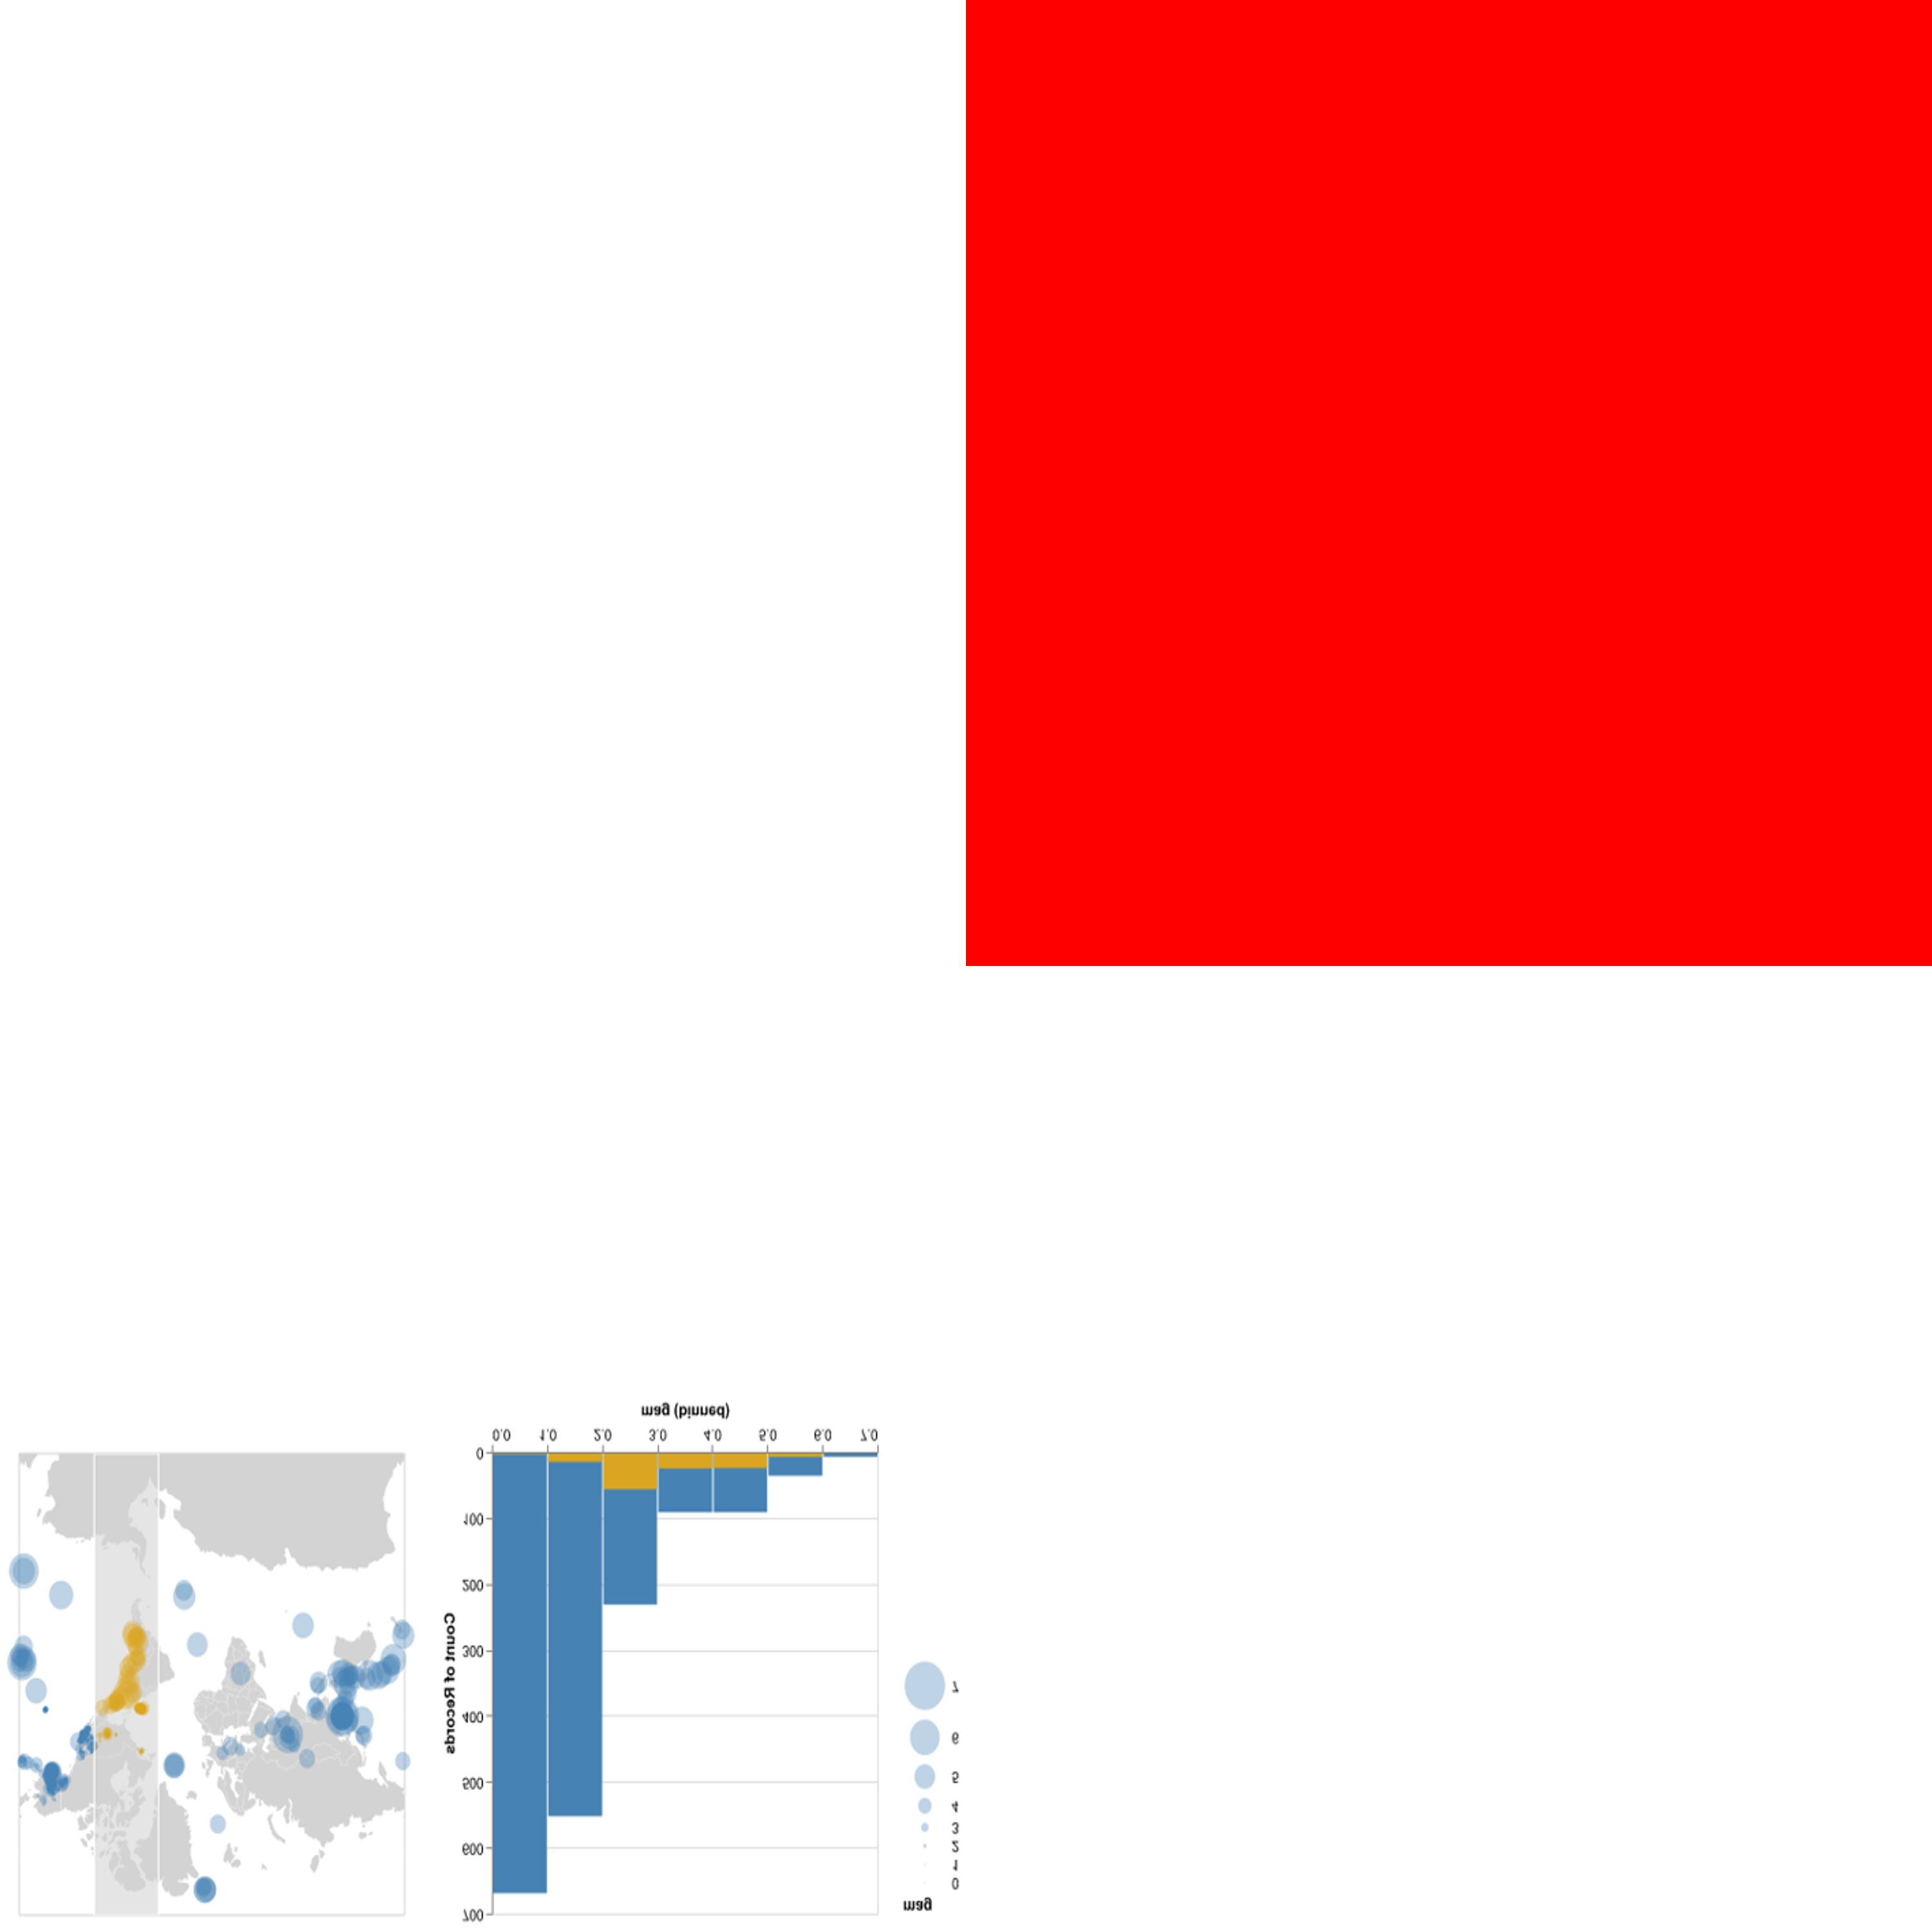

In [5]:
# Select the "Mouse Pad" variant
my_id = "my_mousepad_id"
my_variant = next(variant for variant in products_json['variants'] if variant['id'] == my_id)

# Create the tiled image
image_data = new_create_tiled_image(my_variant)

# Display the result in the notebook
IPythonImage(image_data)